# 看得懂的中介路径模拟：HDMT、MDACT 与 MLFDR

这里重新设计一个简单的数据生成机制：**随机分组 → 固定路径效应 → 加入随机噪声**。读者先理解哪条路径是真中介，再观察三种方法如何判断。

和 `01_simulation_workbench.ipynb` 相比，只改变数据生成：暴露组／对照组人数固定各半，四类路径数固定，非零α、β和直接效应固定，不再随机抽取每条路径的效应系数。**三个方法及选项、n=300、m=1000、τ=1.3/1.5/1.9、稀疏／密集比例、三个场景、每条件40次、q=0.05、FDR／Power定义、MCSE／区间、配对比较和主图均保持一致。**

本 notebook 使用 R 内核。先生成 RDS 和示例 CSV，再从文件读入并比较；代码区开头集中参数。开发检查用 seed=20261008、每条件3次；正式运行预先固定 seed=20261010、每条件40次，全部重复保留。

In [1]:
find_project_root <- function(start = getwd()) {
  path <- normalizePath(start, winslash="/", mustWork=TRUE)
  for (i in 1:6) {
    if (file.exists(file.path(path, "R", "bootstrap.R"))) return(path)
    candidate <- file.path(path, "mlfdr_simulation_lab")
    if (file.exists(file.path(candidate, "R", "bootstrap.R"))) return(candidate)
    path <- dirname(path)
  }
  stop("请从工程目录或 notebooks 目录启动 Jupyter。")
}
PROJECT_ROOT <- find_project_root()
source(file.path(PROJECT_ROOT, "R", "bootstrap.R"), encoding="UTF-8")
options(repr.plot.width=10, repr.plot.height=7, repr.plot.res=145,
        repr.matrix.max.rows=40, repr.matrix.max.cols=15)
check_dependencies()

# 参数控制区。teaching_fixed 的效应系数固定，因此三个系数随机方差须为0。
config <- default_config("teaching")
config$seed <- 20261010L
config$dgp_profile <- "teaching_fixed"
config$n <- 300L
config$m <- 1000L
config$tau <- c(1.3, 1.5, 1.9)
config$repetitions <- 40L
config$scenarios <- c("linear", "confounded", "binary")
config$mixtures <- list(sparse=c(H00=.88,H10=.05,H01=.05,H11=.02),
                        dense=c(H00=.4,H10=.2,H01=.2,H11=.2))
config$exposure_probability <- .5  # 固定约n/2人暴露，再随机打乱受试者顺序
config$alpha_mean_scale <- .2     # 非零α = .2*tau
config$beta_mean_scale <- .5      # 非零β = .5*tau
config$alpha_noise_variance <- 0
config$beta_noise_variance <- 0
config$direct_mean <- .2          # X直接作用于Y的系数
config$direct_sd <- 0
config$error_sd_m <- 1
config$error_sd_y <- 1
config$confounder_max <- .3       # 此profile中θ=δ=.3，均为固定值
config$q <- .05
config$methods <- c("HDMT", "MDACT", "MLFDR")
config$method_options <- list(HDMT=list(exact=0L), MDACT=list(),
  MLFDR=list(engine="paper_em",eps=1e-4,max_iter=2000L,n_starts=3L))
config$workers <- 4L
config$export_first_long_csv <- TRUE
validate_config(config)
estimate_storage(config)

,package,version
,<chr>,<chr>
HDMT,HDMT,1.0.5
MLFDR,MLFDR,0.1.0
NMOF,NMOF,2.11.0
ggplot2,ggplot2,4.0.3
IRkernel,IRkernel,1.3.2


datasets,method_fits,raw_matrix_GiB
<int>,<int>,<dbl>
720,2160,3.219


## 一份数据怎么产生

设想300名受试者被随机分入对照组X=0和暴露组X=1，各150人。每条候选路径都有一组中介M和结局Y。1000列代表1000条平行的候选路径，共享同一个X；每列的M和Y对应同一条路径。沿用原实验的路径筛选数据结构，便于复用完全相同的分析代码。

对于连续结局，每条路径按下面两式生成：

\[
M_i=\alpha_iX+e_i,\qquad Y_i=0.2X+\beta_iM_i+\varepsilon_i,
\quad e_i,\varepsilon_i\sim N(0,1).
\]

α表示从X到M的影响，β表示调整X后从M到Y的影响。只有两段都有效，X才通过M传递到Y；连续线性模型的间接效应为αβ。

| 路径类型 | α | β | 稀疏场景条数 | 密集场景条数 | 是否是真中介 |
|:--|--:|--:|--:|--:|:--|
| H00：两段都无效 | 0 | 0 | 880 | 400 | 否 |
| H10：只有X→M有效 | 0.2τ | 0 | 50 | 200 | 否 |
| H01：只有M→Y有效 | 0 | 0.5τ | 50 | 200 | 否 |
| H11：两段都有效 | 0.2τ | 0.5τ | 20 | 200 | 是 |

先按比例确定条数，再随机打乱路径顺序。修改m或比例后，用最大余数法取整数，使总条数恰好等于m。因每条有效路径使用同一个效应值，模型更容易解释；重复间仍有随机分组、路径顺序、噪声以及二元结局抽样的变化。

三个场景继续保留：

1. **线性**：上述两式。
2. **已测混杂**：Z~N(0,1)，M和Y各额外加0.3Z；分析时两个回归都调整Z。
3. **二元结局**：M仍按第一式生成；Y~Bernoulli(plogis(0.2X+βM))。β为条件log odds系数，αβ不直接解释为发生概率之差。

α的标准误约为1/√(300×0.5×0.5)=0.115；三个τ下α=0.26/0.30/0.38，约对应2.3/2.6/3.3个标准误。这样能观察中等至较强的信号，而不会所有方法从一开始就接近100%功效。这是预先设计的可检测性考虑，未按方法排名筛选种子或重复。

In [2]:
data.frame(tau=config$tau, nonzero_alpha=config$alpha_mean_scale*config$tau,
           nonzero_beta=config$beta_mean_scale*config$tau,
           linear_indirect_effect=config$alpha_mean_scale*config$beta_mean_scale*config$tau^2)

tau,nonzero_alpha,nonzero_beta,linear_indirect_effect
<dbl>,<dbl>,<dbl>,<dbl>
1.3,0.26,0.65,0.169
1.5,0.30,0.75,0.225
1.9,0.38,0.95,0.361


## 先生成数据并保存文件

此处仅生成数据。全部720份原始数据保存为RDS；`manifest.csv`保存种子、条件、文件名与MD5。第一份数据同时导出长表`example_long.csv`和独立真值表。原始数据只保存在本地，可由生成代码重建。

In [3]:
generated <- generate_data_files(config, PROJECT_ROOT)
MANIFEST_PATH <- file.path(generated$directory, "manifest.rds")
cat("数据文件入口：", MANIFEST_PATH, "\n")
cat("已保存数据：", nrow(generated$design), "份\n")
head(generated$design[,c("case_id","scenario","mixture","n","tau","replicate","seed","file")],8)

Data saved/checked: 1/720



Data saved/checked: 20/720



Data saved/checked: 40/720



Data saved/checked: 60/720



Data saved/checked: 80/720



...

Data saved/checked: 700/720



Data saved/checked: 720/720



数据文件入口： D:/A_Mediation_analysis/code/mlfdr_simulation_lab/data/data_c054ed713a76/manifest.rds 


已保存数据： 720 份


,case_id,scenario,mixture,n,tau,replicate,seed,file
,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<chr>
1,linear_sparse_n300_t01_r0001,linear,sparse,300,1.3,1,203874798,linear_sparse_n300_t01_r0001.rds
2,confounded_sparse_n300_t01_r0001,confounded,sparse,300,1.3,1,96903160,confounded_sparse_n300_t01_r0001.rds
3,binary_sparse_n300_t01_r0001,binary,sparse,300,1.3,1,1200593,binary_sparse_n300_t01_r0001.rds
4,linear_dense_n300_t01_r0001,linear,dense,300,1.3,1,190837284,linear_dense_n300_t01_r0001.rds
5,confounded_dense_n300_t01_r0001,confounded,dense,300,1.3,1,211343690,confounded_dense_n300_t01_r0001.rds
6,binary_dense_n300_t01_r0001,binary,dense,300,1.3,1,167861328,binary_dense_n300_t01_r0001.rds
7,linear_sparse_n300_t02_r0001,linear,sparse,300,1.5,1,154146653,linear_sparse_n300_t02_r0001.rds
8,confounded_sparse_n300_t02_r0001,confounded,sparse,300,1.5,1,154118143,confounded_sparse_n300_t02_r0001.rds


## 从文件读取，确认数据符合设计

选择中间τ的密集线性数据作直观示例；下面使用真值来解释四类路径。真值不会传给比较方法。更改场景后，如没有线性条件，则读取第一份可用数据。

In [4]:
manifest <- read_manifest(MANIFEST_PATH)
middle_tau <- config$tau[ceiling(length(config$tau)/2)]
example_idx <- which(manifest$design$scenario=="linear" & manifest$design$mixture=="dense" &
                       manifest$design$tau==middle_tau & manifest$design$replicate==1L)
if (!length(example_idx)) example_idx <- 1L
example_data <- read_dataset(manifest, manifest$design$case_id[example_idx[1]])
data.frame(n=nrow(example_data$M),m=ncol(example_data$M),
           control=sum(example_data$X==0),exposed=sum(example_data$X==1),
           true_mediators=sum(example_data$truth$is_nonnull))
IRdisplay::display(as.data.frame(table(example_data$truth$state)))
IRdisplay::display(head(utils::read.csv(file.path(manifest$directory,"example_long.csv")),8))

n,m,control,exposed,true_mediators
<int>,<int>,<int>,<int>,<int>
300,1000,150,150,200


Var1,Freq
<fct>,<int>
H00,400
H01,200
H10,200
H11,200


,subject_id,pathway_id,X,Z,M,Y
,<int>,<chr>,<int>,<lgl>,<dbl>,<dbl>
1,1,pathway_0001,0,NA,0.1099388,0.3825804
2,2,pathway_0001,1,NA,1.1012390,-0.6312758
3,3,pathway_0001,0,NA,-0.4174423,-0.8487622
4,4,pathway_0001,0,NA,-1.0774699,0.3165760
5,5,pathway_0001,1,NA,-0.3107081,0.1043453
6,6,pathway_0001,1,NA,0.4348691,-0.5062838
7,7,pathway_0001,0,NA,-0.7711763,0.7036926
8,8,pathway_0001,1,NA,1.7666575,1.2895771


## 用四条路径看懂α和β

从每类中选择一条路径。第一张图比较暴露组和对照组的M，对应α；第二张图先从M和Y中去除X的线性影响，再展示剩余部分之间的关系，对应调整X后的β。直线为样本回归，噪声使其与真实值略有差异。这一演示使用线性场景。

,pathway_id,state,alpha,beta,is_nonnull
,<chr>,<chr>,<dbl>,<dbl>,<lgl>
9,pathway_0009,H00,0.0,0.00,FALSE
3,pathway_0003,H10,0.3,0.00,FALSE
1,pathway_0001,H01,0.0,0.75,FALSE
8,pathway_0008,H11,0.3,0.75,TRUE


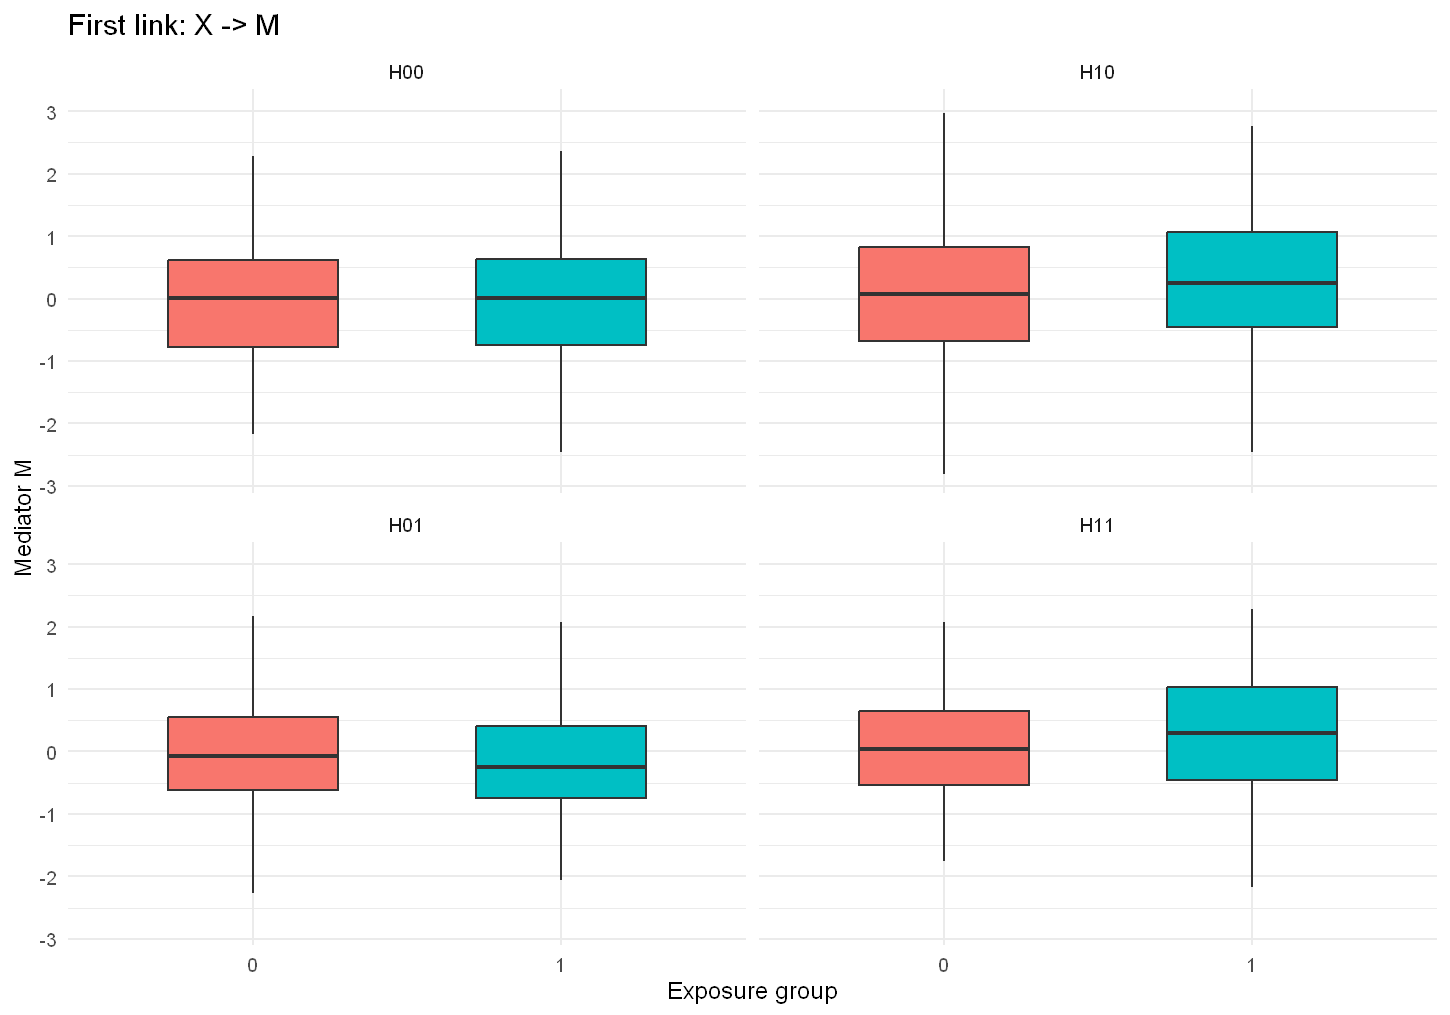

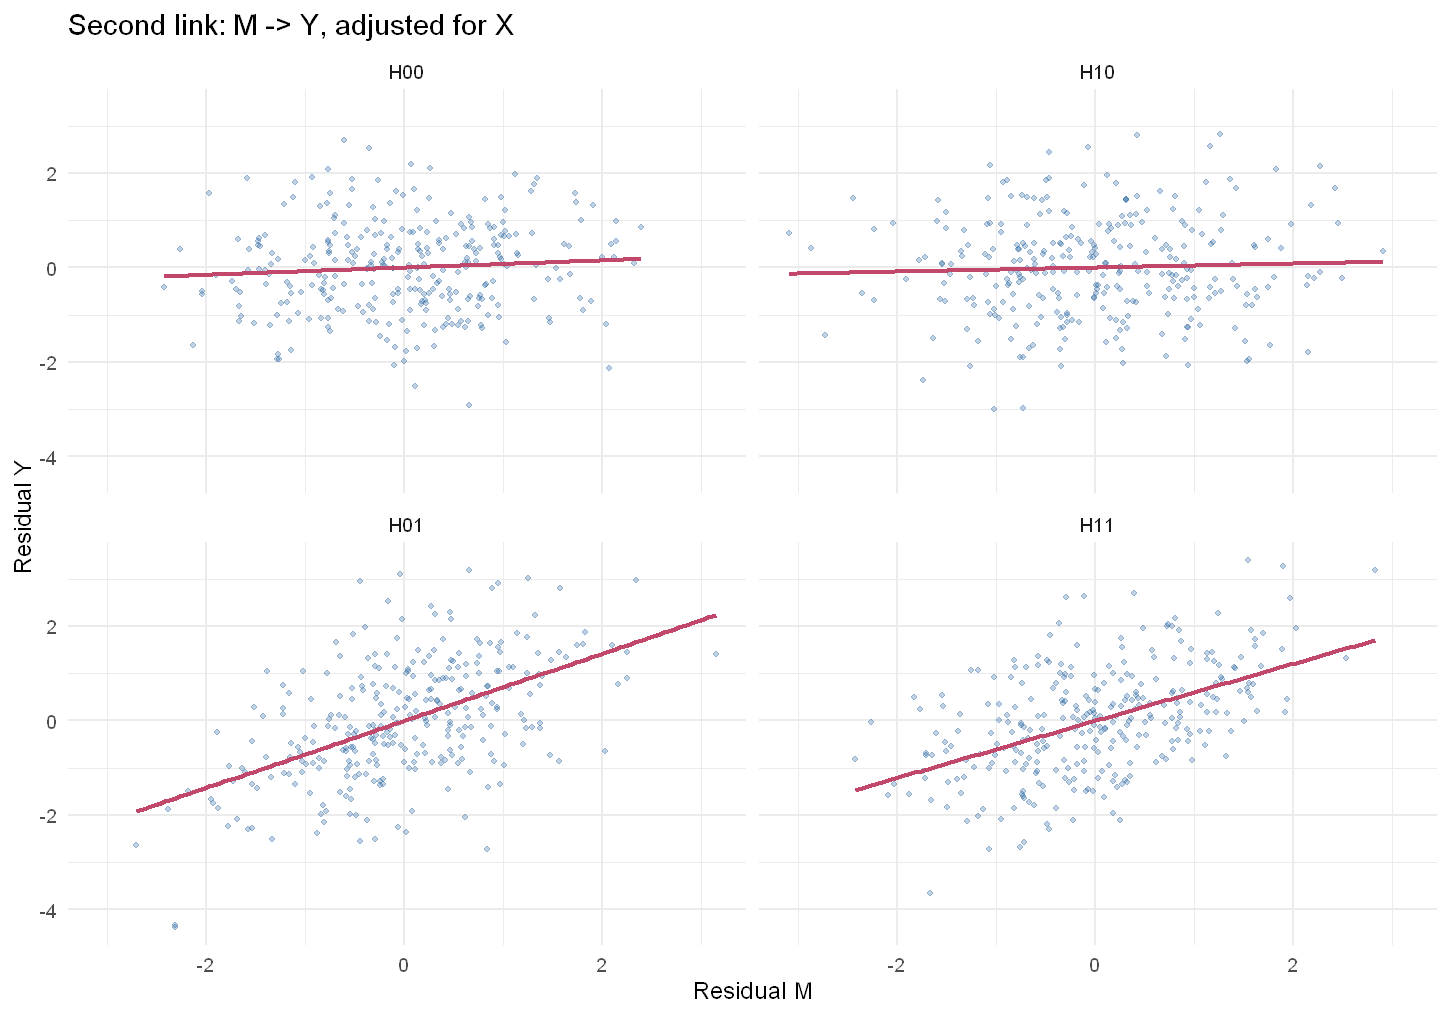

In [5]:
illustration_dir <- ensure_dir(file.path(PROJECT_ROOT,"docs","teaching_figures"))
present_states <- intersect(c("H00","H10","H01","H11"), example_data$truth$state)
demo_j <- vapply(present_states,function(s) which(example_data$truth$state==s)[1],integer(1))
IRdisplay::display(example_data$truth[demo_j,c("pathway_id","state","alpha","beta","is_nonnull")])
if (example_data$meta$scenario=="linear") {
  demo <- do.call(rbind,lapply(demo_j,function(j) {
    d <- data.frame(X=example_data$X,M=example_data$M[,j],Y=example_data$Y[,j])
    data.frame(state=example_data$truth$state[j],X=factor(d$X),M=d$M,
               residual_M=residuals(lm(M~X,d)),residual_Y=residuals(lm(Y~X,d)))
  }))
  demo$state <- factor(demo$state,levels=c("H00","H10","H01","H11"))
  p_alpha <- ggplot2::ggplot(demo,ggplot2::aes(X,M,fill=X))+
    ggplot2::geom_boxplot(width=.55,outlier.shape=NA)+
    ggplot2::facet_wrap(~state,ncol=2)+ggplot2::theme_minimal(base_size=12)+
    ggplot2::labs(title="First link: X -> M",x="Exposure group",y="Mediator M")+
    ggplot2::theme(legend.position="none")
  p_beta <- ggplot2::ggplot(demo,ggplot2::aes(residual_M,residual_Y))+
    ggplot2::geom_point(alpha=.3,size=1,color="#2864A0")+
    ggplot2::geom_smooth(method="lm",formula=y~x,se=FALSE,color="#C1486A")+
    ggplot2::facet_wrap(~state,ncol=2)+ggplot2::theme_minimal(base_size=12)+
    ggplot2::labs(title="Second link: M -> Y, adjusted for X",x="Residual M",y="Residual Y")
  print(p_alpha)
  print(p_beta)
  ggplot2::ggsave(file.path(illustration_dir,"first_link.png"),p_alpha,width=10,height=7,dpi=160,bg="white")
  ggplot2::ggsave(file.path(illustration_dir,"second_link.png"),p_beta,width=10,height=7,dpi=160,bg="white")
}

## 方法和比较指标：与上一版一致

三个方法调用相同的适配器和选项：HDMT已安装包；MDACT作者公式及等价解析CDF实现；MLFDR的论文四成分`paper_em`后端（包括允许零先验方差、√n缩放、3个固定起点）。这里没有为了新数据修改方法。原包MLFDR仍可通过`engine="package"`切换。

所有方法读取相同的OLS／logistic系数及标准误；已测混杂场景调整Z。输入包括观测数据和估计量，排除真实路径状态与真实系数。

每次重复计算发现数R、假发现数V、真发现数S以及真实中介数A：FDP=V/max(R,1)，Power=S/A；经验FDR是40次FDP的平均。q=0.05是目标。MCSE=重复间SD/√40；主图阴影为与旧版相同的近似95%蒙特卡洛均值区间。功效差异在同一数据重复内配对计算；失败按NA记录。超出目标的实际FDR仍如实显示。

In [6]:
registry <- load_method_registry(PROJECT_ROOT)
IRdisplay::display(registry_info(registry[config$methods]))
example_estimates <- estimate_coefficients(example_data)$estimates
stopifnot(!("truth" %in% names(make_method_input(example_data,example_estimates))))
head(example_estimates,6)

,method,adapter_version,packages,description
,<chr>,<chr>,<chr>,<chr>
HDMT,HDMT,1.0.0,HDMT,HDMT::fdr_est (paper uses exact=0)
MDACT,MDACT,1.1.0,HDMT,Author MDACT FDR threshold with equivalent analytic null CDF
MLFDR,MLFDR,2.0.0,MLFDR,Paper four-state EM or MLFDR::localFDR + adaptive step-up; engine in config


,pathway_id,alpha_hat,beta_hat,var_alpha,var_beta,se_alpha,se_beta,p_alpha,p_beta
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
pathway_0001,pathway_0001,-0.09341045,0.71046750,0.01167046,0.004482782,0.1080299,0.06695358,0.38791417,1.000000e-17
pathway_0002,pathway_0002,-0.01264594,0.71938103,0.01261267,0.003384415,0.1123061,0.05817573,0.91042157,1.000000e-17
pathway_0003,pathway_0003,0.20494677,0.04235802,0.01491862,0.003268810,0.1221418,0.05717351,0.09440699,4.593588e-01
pathway_0004,pathway_0004,0.01136044,0.76751018,0.01406780,0.003066749,0.1186078,0.05537824,0.92375841,1.000000e-17
pathway_0005,pathway_0005,-0.14088034,0.67699253,0.01439206,0.002711199,0.1199669,0.05206918,0.24120186,1.000000e-17
pathway_0006,pathway_0006,0.16580108,0.67970275,0.01401237,0.003625452,0.1183739,0.06021173,0.16235729,1.000000e-17


## 运行比较并保存结果

调用与上一版完全相同的实验与汇总函数。独立的`current_teaching.rds`记录新实验入口；原notebook的入口不被覆盖。

In [7]:
experiment <- run_experiment(manifest,config,PROJECT_ROOT,registry)
artifacts <- save_comparison_artifacts(experiment,PROJECT_ROOT)
summary_table <- experiment$summary
atomic_save_rds(list(output_dir=experiment$output_dir,manifest_path=MANIFEST_PATH,config=config),
                file.path(PROJECT_ROOT,"docs","current_teaching.rds"))
writeLines(c(paste0("run_dir=",experiment$output_dir),paste0("manifest_path=",MANIFEST_PATH)),
           file.path(PROJECT_ROOT,"docs","current_teaching.txt"))
cat("结果目录：",experiment$output_dir,"\n")
cat("成功调用：",sum(experiment$metrics$status=="ok"),"/",nrow(experiment$metrics),"\n")
cat("有警告的调用：",sum(nzchar(experiment$metrics$warning)),"\n")

Analysed 12/720 saved datasets; method errors: 0



Analysed 24/720 saved datasets; method errors: 0



Analysed 36/720 saved datasets; method errors: 0



Analysed 48/720 saved datasets; method errors: 0



Analysed 60/720 saved datasets; method errors: 0



...

Analysed 708/720 saved datasets; method errors: 0



Analysed 720/720 saved datasets; method errors: 0



结果目录： D:/A_Mediation_analysis/code/mlfdr_simulation_lab/results/run_af52854e0ae0 


成功调用： 2160 / 2160 


有警告的调用： 960 


## 线性模型：FDR 和 Power

图形布局与上一版一致：左列FDR，右列Power；上排稀疏，下排密集。虚线为0.05。表格保留成功数、错误数、警告数与MCSE。

,mixture,n,tau,method,n_success,n_error,n_warning,FDR_mean,FDR_mcse,power_mean,power_mcse
,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
37,dense,300,1.3,HDMT,40,0,40,0.0307,0.0030,0.3190,0.0087
38,dense,300,1.3,MDACT,40,0,40,0.0419,0.0034,0.3781,0.0095
39,dense,300,1.3,MLFDR,40,0,0,0.0498,0.0031,0.6491,0.0066
40,dense,300,1.5,HDMT,40,0,40,0.0345,0.0029,0.5171,0.0115
41,dense,300,1.5,MDACT,40,0,40,0.0388,0.0029,0.5630,0.0119
42,dense,300,1.5,MLFDR,40,0,0,0.0496,0.0024,0.7979,0.0073
43,dense,300,1.9,HDMT,40,0,40,0.0418,0.0027,0.8125,0.0053
44,dense,300,1.9,MDACT,40,0,40,0.0458,0.0028,0.8299,0.0065
45,dense,300,1.9,MLFDR,40,0,0,0.0499,0.0023,0.9530,0.0031


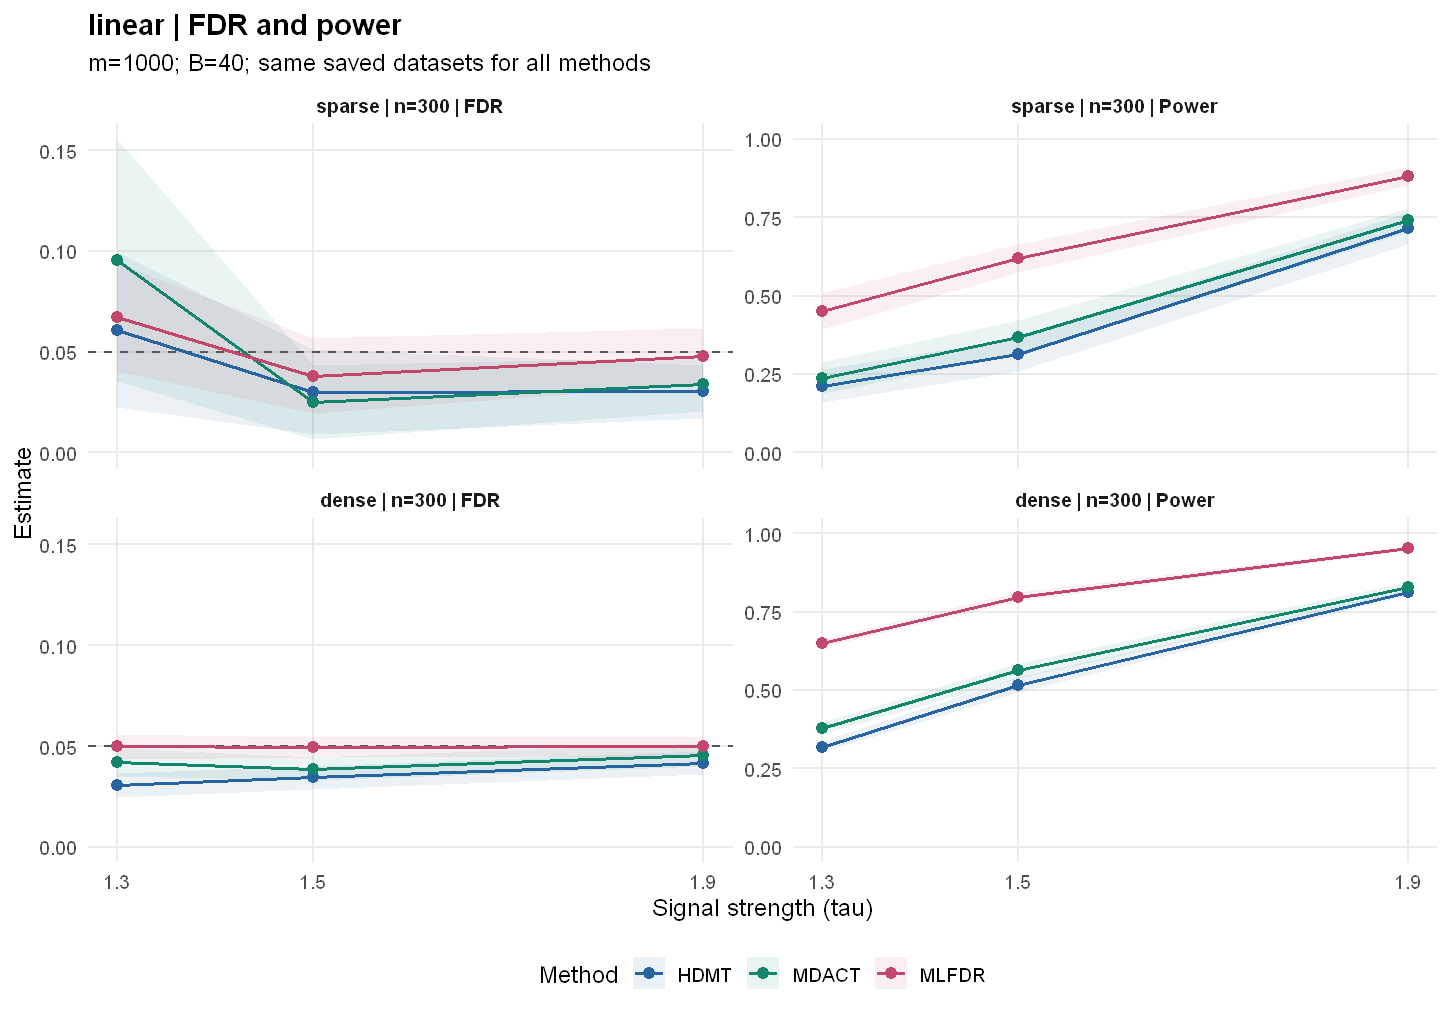

In [8]:
if ("linear" %in% config$scenarios) {
  print(plot_paper_comparison(summary_table,"linear"))
  tab <- summary_table[summary_table$scenario=="linear",
    c("mixture","n","tau","method","n_success","n_error","n_warning","FDR_mean","FDR_mcse","power_mean","power_mcse")]
  numeric_columns <- vapply(tab,is.numeric,logical(1))
  tab[numeric_columns] <- lapply(tab[numeric_columns],round,digits=4)
  IRdisplay::display(tab)
}

## 已测混杂模型：FDR 和 Power

图形布局与上一版一致：左列FDR，右列Power；上排稀疏，下排密集。虚线为0.05。表格保留成功数、错误数、警告数与MCSE。

,mixture,n,tau,method,n_success,n_error,n_warning,FDR_mean,FDR_mcse,power_mean,power_mcse
,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
19,dense,300,1.3,HDMT,40,0,40,0.0288,0.0028,0.3234,0.0091
20,dense,300,1.3,MDACT,40,0,40,0.0397,0.0032,0.3871,0.0091
21,dense,300,1.3,MLFDR,40,0,0,0.0489,0.0028,0.6648,0.0065
22,dense,300,1.5,HDMT,40,0,40,0.0365,0.0039,0.5145,0.0071
23,dense,300,1.5,MDACT,40,0,40,0.0437,0.0041,0.5648,0.0075
24,dense,300,1.5,MLFDR,40,0,0,0.0528,0.0029,0.8138,0.0058
25,dense,300,1.9,HDMT,40,0,40,0.0392,0.0029,0.8120,0.0073
26,dense,300,1.9,MDACT,40,0,40,0.0431,0.0034,0.8282,0.0062
27,dense,300,1.9,MLFDR,40,0,0,0.0490,0.0023,0.9441,0.0028


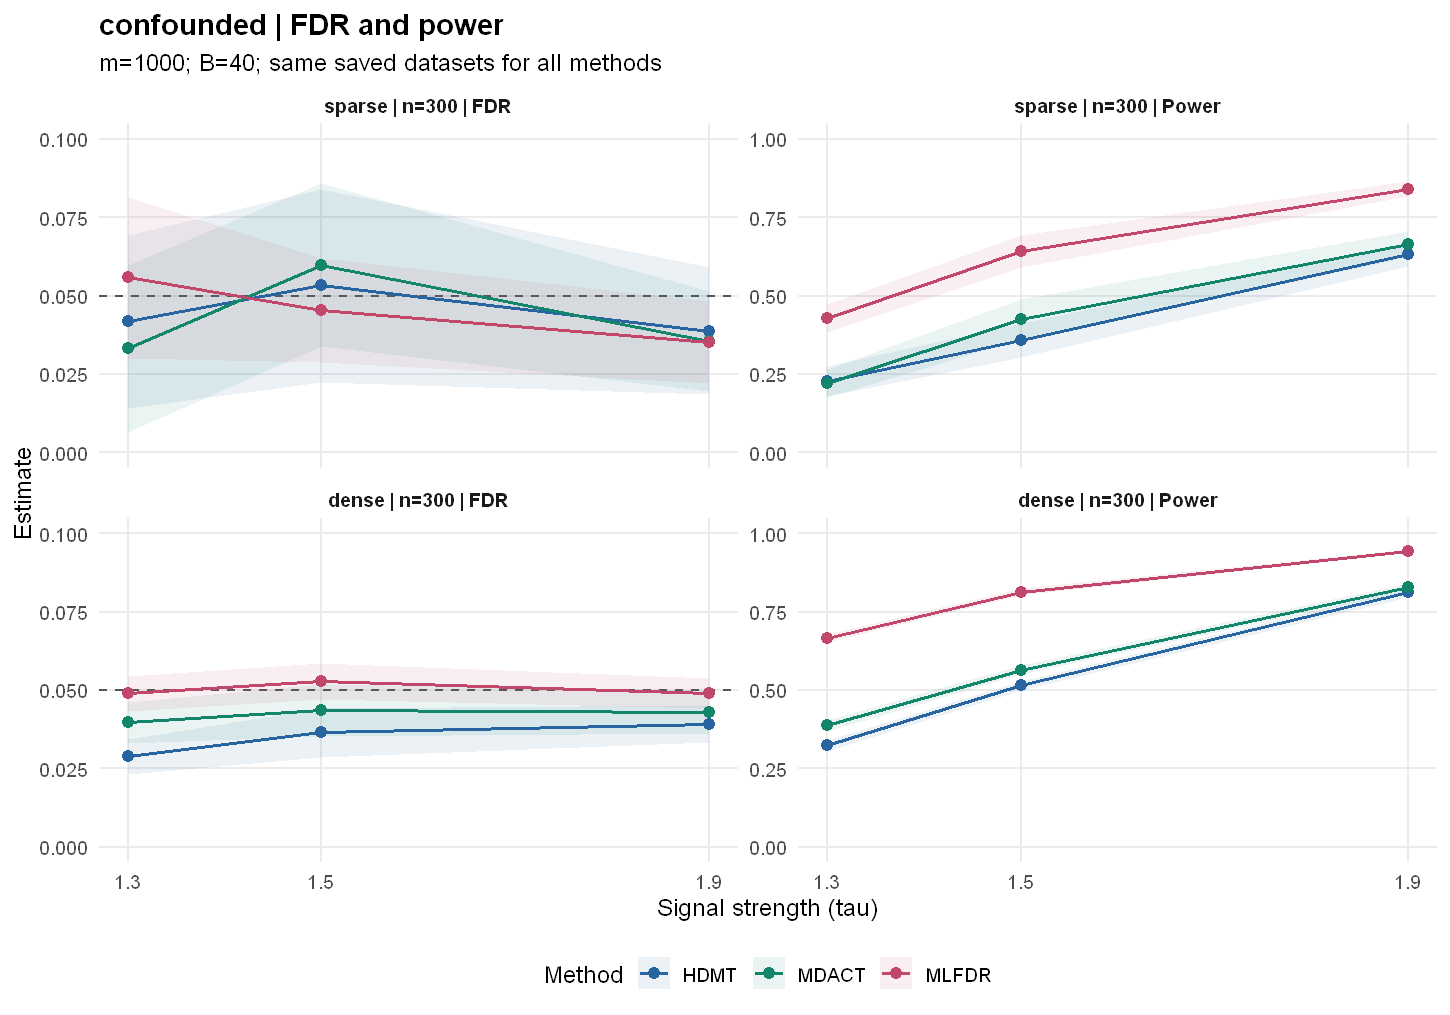

In [9]:
if ("confounded" %in% config$scenarios) {
  print(plot_paper_comparison(summary_table,"confounded"))
  tab <- summary_table[summary_table$scenario=="confounded",
    c("mixture","n","tau","method","n_success","n_error","n_warning","FDR_mean","FDR_mcse","power_mean","power_mcse")]
  numeric_columns <- vapply(tab,is.numeric,logical(1))
  tab[numeric_columns] <- lapply(tab[numeric_columns],round,digits=4)
  IRdisplay::display(tab)
}

## 二元结局模型：FDR 和 Power

图形布局与上一版一致：左列FDR，右列Power；上排稀疏，下排密集。虚线为0.05。表格保留成功数、错误数、警告数与MCSE。

,mixture,n,tau,method,n_success,n_error,n_warning,FDR_mean,FDR_mcse,power_mean,power_mcse
,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,dense,300,1.3,HDMT,40,0,0,0.0252,0.0034,0.3260,0.0094
2,dense,300,1.3,MDACT,40,0,0,0.0331,0.0033,0.3838,0.0083
3,dense,300,1.3,MLFDR,40,0,0,0.0496,0.0021,0.6522,0.0065
4,dense,300,1.5,HDMT,40,0,0,0.0295,0.0028,0.5098,0.0097
5,dense,300,1.5,MDACT,40,0,0,0.0377,0.0029,0.5650,0.0102
6,dense,300,1.5,MLFDR,40,0,0,0.0483,0.0031,0.8012,0.0060
7,dense,300,1.9,HDMT,40,0,0,0.0360,0.0028,0.8109,0.0072
8,dense,300,1.9,MDACT,40,0,0,0.0399,0.0028,0.8304,0.0070
9,dense,300,1.9,MLFDR,40,0,0,0.0470,0.0019,0.9478,0.0032


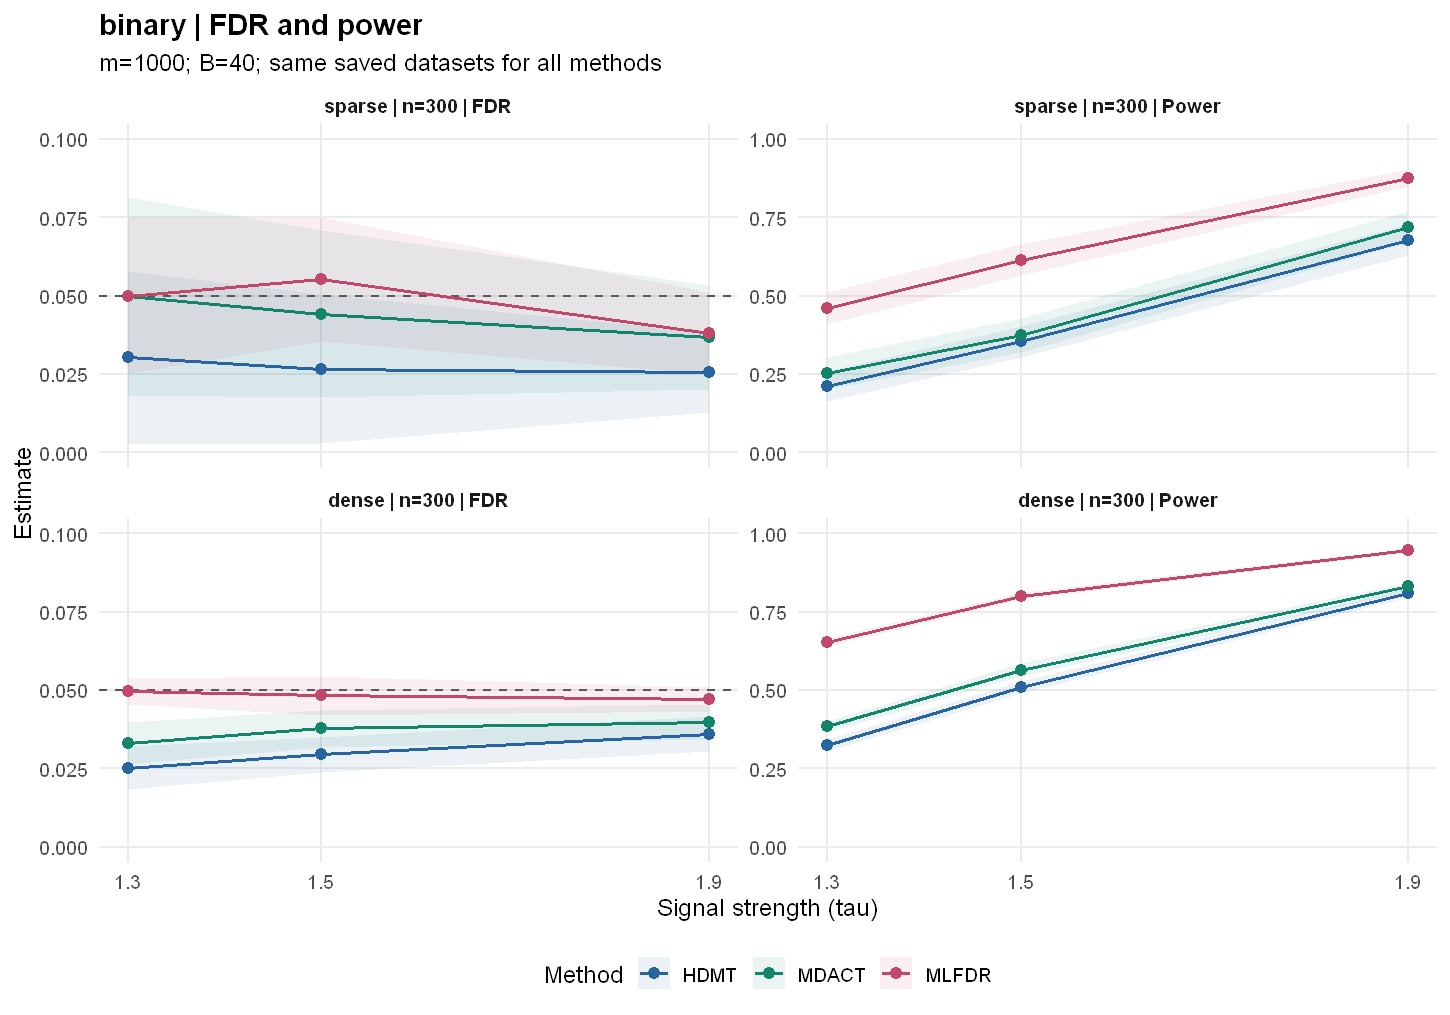

In [10]:
if ("binary" %in% config$scenarios) {
  print(plot_paper_comparison(summary_table,"binary"))
  tab <- summary_table[summary_table$scenario=="binary",
    c("mixture","n","tau","method","n_success","n_error","n_warning","FDR_mean","FDR_mcse","power_mean","power_mcse")]
  numeric_columns <- vapply(tab,is.numeric,logical(1))
  tab[numeric_columns] <- lapply(tab[numeric_columns],round,digits=4)
  IRdisplay::display(tab)
}

## 在相同数据上比较功效差异

展示中间τ的配对差异：MLFDR减HDMT，以及MLFDR减MDACT。单位为百分点。完整结果含全部τ，保存在`paired_differences.csv`。区间下限为正支持本条件下的功效差异；同时需要查看FDR。

In [11]:
paired <- artifacts$paired
tab <- paired[paired$tau==middle_tau,c("scenario","mixture","tau","comparison","n_pairs",
                                      "delta_power_mean","delta_power_lo","delta_power_hi")]
for (key in c("delta_power_mean","delta_power_lo","delta_power_hi")) tab[[key]] <- round(100*tab[[key]],2)
tab

,scenario,mixture,tau,comparison,n_pairs,delta_power_mean,delta_power_lo,delta_power_hi
,<chr>,<chr>,<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>
7,binary,dense,1.5,MLFDR - HDMT,40,29.15,27.60,30.70
8,confounded,dense,1.5,MLFDR - HDMT,40,29.92,28.49,31.36
9,linear,dense,1.5,MLFDR - HDMT,40,28.08,26.23,29.92
10,binary,sparse,1.5,MLFDR - HDMT,40,26.12,21.58,30.67
11,confounded,sparse,1.5,MLFDR - HDMT,40,28.25,23.79,32.71
12,linear,sparse,1.5,MLFDR - HDMT,40,30.63,25.87,35.38
25,binary,dense,1.5,MLFDR - MDACT,40,23.62,22.10,25.15
26,confounded,dense,1.5,MLFDR - MDACT,40,24.90,23.47,26.33
27,linear,dense,1.5,MLFDR - MDACT,40,23.49,21.63,25.34


## 解释实际结果，并检查校准

下面的文字和表格由真实结果生成。即使某个方法的FDR偏高，也不更改阈值或删除重复来让曲线更漂亮。区间下限高于q的条件作为校准提示；近似区间和多条件检查不是联合保证。

稀疏场景每份数据只有20条真中介。发现数较少时，一两条误报就能使FDP明显上升，40次平均的FDR区间会较宽。提示列表为空也不能证明每个条件严格控制在0.05以内。方法警告完整记录在`diagnostics.csv`；常见KS提示来自强β的p值在下界出现并列，仍需结合实际FDR判断。

In [12]:
middle <- summary_table[summary_table$tau==middle_tau,
  c("scenario","mixture","method","FDR_mean","power_mean","FDR_mcse","power_mcse")]
middle[vapply(middle,is.numeric,logical(1))] <- lapply(middle[vapply(middle,is.numeric,logical(1))],round,4)
IRdisplay::display(middle)
flags <- summary_table[is.finite(summary_table$FDR_lo) & summary_table$FDR_lo>summary_table$q,
  c("scenario","mixture","tau","method","FDR_mean","FDR_lo","FDR_hi")]
IRdisplay::display(flags)
failed <- experiment$metrics[experiment$metrics$status!="ok",c("case_id","method","error")]
IRdisplay::display(failed)
cat("MLFDR EM收敛：",sum(artifacts$fits$converged),"/",nrow(artifacts$fits),"\n")
IRdisplay::display(artifacts$fits[!artifacts$fits$converged,])
text <- sprintf("全部条件FDR均值范围为 **%.4f–%.4f**，Power范围为 **%.4f–%.4f**。共有%d个FDR区间下限高于目标的条件；所有条件的实际值已在上表保留。",
  min(summary_table$FDR_mean,na.rm=TRUE),max(summary_table$FDR_mean,na.rm=TRUE),
  min(summary_table$power_mean,na.rm=TRUE),max(summary_table$power_mean,na.rm=TRUE),nrow(flags))
IRdisplay::display_markdown(text)

,scenario,mixture,method,FDR_mean,power_mean,FDR_mcse,power_mcse
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
4,binary,dense,HDMT,0.0295,0.5098,0.0028,0.0097
5,binary,dense,MDACT,0.0377,0.5650,0.0029,0.0102
6,binary,dense,MLFDR,0.0483,0.8012,0.0031,0.0060
13,binary,sparse,HDMT,0.0266,0.3538,0.0118,0.0240
14,binary,sparse,MDACT,0.0442,0.3738,0.0132,0.0272
15,binary,sparse,MLFDR,0.0553,0.6150,0.0097,0.0244
22,confounded,dense,HDMT,0.0365,0.5145,0.0039,0.0071
23,confounded,dense,MDACT,0.0437,0.5648,0.0041,0.0075
24,confounded,dense,MLFDR,0.0528,0.8138,0.0029,0.0058


scenario,mixture,tau,method,FDR_mean,FDR_lo,FDR_hi
<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>


case_id,method,error
<chr>,<chr>,<chr>


MLFDR EM收敛： 720 / 720 


case_id,converged,iterations,mu,theta,kappa,psi,pi00,pi10,pi01,pi11,selected_start,loglik
<chr>,<lgl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>


全部条件FDR均值范围为 **0.0251–0.0956**，Power范围为 **0.2125–0.9530**。共有0个FDR区间下限高于目标的条件；所有条件的实际值已在上表保留。

**怎样理解差异？** H10和H01都不是中介，即使其中一段很显著，仍需要防止误报。HDMT和MDACT主要根据两段p值及零假设混合来筛选；MLFDR联合利用效应方向、大小、标准误和估计的四类路径密度。本数据的非零α、β都是固定的正值，适合用零先验方差的混合成分描述，可能有利于MLFDR。比较支持这里展示的条件，不是三种方法对所有分布的普遍排名。

由于新的分组比例、方向及效应分布都改变了，两个notebook的Power差异不能单独解释为某个方法实现变好；更合适的比较是在同一个notebook、同一份数据内比较三种方法。

## 查看一次重复的实际发现

这里读取方法已经保存的拒绝向量，再用真值计算发现数和错误数。此步骤属于评估，真值仍未进入方法拟合。

In [13]:
case_id <- example_data$meta$case_id
rows <- experiment$metrics[experiment$metrics$case_id==case_id,
  c("method","discoveries","false_discoveries","true_discoveries","alternatives","FDP","power")]
IRdisplay::display(rows)
results <- get_case_results(experiment,case_id,PROJECT_ROOT)
decisions <- example_data$truth[,c("pathway_id","state","alpha","beta","is_nonnull")]
for (method in config$methods) decisions[[method]] <- if (is.null(results[[method]])) NA else results[[method]]$reject
write_csv(decisions,file.path(experiment$output_dir,"teaching_example_decisions.csv"))
head(decisions,12)

,method,discoveries,false_discoveries,true_discoveries,alternatives,FDP,power
,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>
28,HDMT,79,4,75,200,0.05063291,0.375
29,MDACT,89,4,85,200,0.04494382,0.425
30,MLFDR,153,5,148,200,0.03267974,0.740


,pathway_id,state,alpha,beta,is_nonnull,HDMT,MDACT,MLFDR
,<chr>,<chr>,<dbl>,<dbl>,<lgl>,<lgl>,<lgl>,<lgl>
1,pathway_0001,H01,0.0,0.75,FALSE,FALSE,FALSE,FALSE
2,pathway_0002,H01,0.0,0.75,FALSE,FALSE,FALSE,FALSE
3,pathway_0003,H10,0.3,0.00,FALSE,FALSE,FALSE,FALSE
4,pathway_0004,H01,0.0,0.75,FALSE,FALSE,FALSE,FALSE
5,pathway_0005,H01,0.0,0.75,FALSE,FALSE,FALSE,FALSE
6,pathway_0006,H01,0.0,0.75,FALSE,FALSE,FALSE,FALSE
7,pathway_0007,H10,0.3,0.00,FALSE,FALSE,FALSE,FALSE
8,pathway_0008,H11,0.3,0.75,TRUE,FALSE,FALSE,FALSE
9,pathway_0009,H00,0.0,0.00,FALSE,FALSE,FALSE,FALSE


## 修改和加入新方法

- 修改开头的暴露比例、α／β系数、直接效应、噪声或混杂强度即可改变生成机制；四类路径的数量由m与比例确定。该profile使用固定效应，`alpha_noise_variance`、`beta_noise_variance`、`direct_sd`须保持0。
- 分析代码位于同一套`R/`模块。复制`examples/new_method_template.R`至`R/methods/plugins/`，注册方法并追加到`config$methods`；数据和不变方法的缓存可继续复用。接口见`docs/ADDING_METHODS.md`。
- 当前默认重复次数与旧版一致。快速学习时可先设`config$repetitions <- 3L`，但不要用很少的重复断言FDR稳定受控。
- CLI重跑：`Rscript --vanilla scripts/run_experiment.R teaching`。批量执行本notebook：`python scripts/execute_notebook.py notebooks/02_teaching_mediation.ipynb`。
- 源码设计见`docs/TEACHING_SIMULATION.md`；入口在`docs/current_teaching.rds`。`scripts/validate_teaching.R`逐份复核数据和指标。数据留在本地；代码和已执行结果可以进入Git仓库。
- 本notebook的作者脚本`build_teaching_notebook.py`会清除手工修改和输出，日常调参不要运行它。历史结果和原notebook保留在各自目录。